<div align='center'>

#  Prompt Engineering — Advanced Techniques
### ReAct Prompting · Negative Prompting · Interactive Playground

![Python](https://img.shields.io/badge/Python-3.8%2B-blue?style=for-the-badge&logo=python)
![Groq](https://img.shields.io/badge/Groq-LLaMA3-purple?style=for-the-badge)
![GSSoC](https://img.shields.io/badge/GSSoC-2026-orange?style=for-the-badge)
![Interactive](https://img.shields.io/badge/Interactive-Widgets-green?style=for-the-badge)

</div>

---

##  About This Notebook

This notebook is a **continuation and extension** of the Prompt Engineering series for ML-CaPsule.
It covers **2 advanced techniques** not covered in the basic notebook, plus an **interactive playground** for all techniques.

| # | Technique | Type | Real World Use Case |
|---|-----------|------|--------------------|
| 1 | ReAct Prompting |  Advanced | AI Agents, Planning, Research |
| 2 | Negative Prompting |  Intermediate | Content Moderation, Style Control |
| 3 | Interactive Playground |  All Levels | Practice all 7 techniques live |

---

##  Table of Contents
1. [Setup](#1)
2. [ReAct Prompting](#2)
3. [Negative Prompting](#3)
4. [Interactive Playground — All Techniques](#4)
5. [Visualization — Technique Comparison](#5)
6. [Summary & Cheat Sheet](#6)

---

## 1. Setup <a id='1'></a>

In [20]:
!pip install groq matplotlib pandas ipywidgets -q
print('Packages installed!')

Packages installed!


In [21]:
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from getpass import getpass
from groq import Groq

# ── Secure API key entry ──────────────────────────────────────
# Get free key at: https://console.groq.com
api_key = getpass('Enter your Groq API key: ').strip()
if not api_key:
    raise ValueError('Groq API key is required. Please create one at https://console.groq.com and re-run this cell.')
client  = Groq(api_key=api_key)
MODEL   = 'llama-3.3-70b-versatile'

# ── Helper function ───────────────────────────────────────────
def ask(prompt: str, system: str = None, temperature: float = 0.7) -> str:
    """
    Send a prompt to LLaMA3 via Groq and return the response.
    Args:
        prompt      : User message
        system      : Optional system/role message
        temperature : 0=precise, 1=creative
    """
    messages = []
    if system:
        messages.append({'role': 'system', 'content': system})
    messages.append({'role': 'user', 'content': prompt})
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=temperature,
        max_tokens=1000
    )
    return response.choices[0].message.content


def display_result(technique, prompt, response):
    print(f'\n{"="*65}')
    print(f' Technique : {technique}')
    print(f'{"─"*65}')
    print(f' Prompt:\n{prompt}')
    print(f'{"─"*65}')
    print(f' Response:\n{response}')
    print(f'{"="*65}')


# Test
test = ask('Say hello in one sentence!')
print(f' API Connected! Test: {test}')

Enter your Groq API key:  ········


 API Connected! Test: Hello, it's nice to meet you and I'm here to assist you with any questions or topics you'd like to discuss.


---
## 2. ReAct Prompting <a id='2'></a>

**ReAct = Reasoning + Acting**

The model alternates between:
-  **Thought** → What do I know? What do I need to find out?
-  **Action** → What should I do next?
-  **Observation** → What did I learn from that action?

This is the **foundation of AI Agents** — systems that can plan, reason, and take multi-step actions.

```
Question
   ↓
Thought 1 → Action 1 → Observation 1
   ↓
Thought 2 → Action 2 → Observation 2
   ↓
Final Answer
```

### Real World Use Cases:
- **AI Coding Agents** (GitHub Copilot, Cursor AI)
- **Research Agents** (search web → read → summarize → answer)
- **Medical Diagnosis** (check symptom → look up → conclude)
- **Business Planning** (analyze → research → recommend)

In [22]:
print('=' * 65)
print('          ReAct PROMPTING — REAL WORLD EXAMPLES')
print('=' * 65)

# ── Real World Example 1: Medical Symptom Analysis ────────────
# Used in: AI health assistants, medical chatbots
react_medical = """
A patient reports: headache for 3 days, mild fever (99.5°F),
fatigue, and a stiff neck.

As a medical AI assistant, analyze this using:
Thought 1: [what symptoms are present]
Action 1: [what to check/consider first]
Observation 1: [what this tells you]

Thought 2: [next analysis step]
Action 2: [what to evaluate next]
Observation 2: [what this means]

Thought 3: [any red flags?]
Action 3: [urgency assessment]
Observation 3: [conclusion]

Final Recommendation: [clear, actionable advice]

Note: This is for educational purposes only.
"""

response_medical = ask(react_medical, temperature=0.3)
display_result('ReAct | Medical Symptom Analysis', react_medical.strip(), response_medical)
time.sleep(1)

          ReAct PROMPTING — REAL WORLD EXAMPLES

 Technique : ReAct | Medical Symptom Analysis
─────────────────────────────────────────────────────────────────
 Prompt:
A patient reports: headache for 3 days, mild fever (99.5°F),
fatigue, and a stiff neck.

As a medical AI assistant, analyze this using:
Thought 1: [what symptoms are present]
Action 1: [what to check/consider first]
Observation 1: [what this tells you]

Thought 2: [next analysis step]
Action 2: [what to evaluate next]
Observation 2: [what this means]

Thought 3: [any red flags?]
Action 3: [urgency assessment]
Observation 3: [conclusion]

Final Recommendation: [clear, actionable advice]

Note: This is for educational purposes only.
─────────────────────────────────────────────────────────────────
 Response:
**Thought 1: Identifying Present Symptoms**
The patient is experiencing a headache, mild fever (99.5°F), fatigue, and a stiff neck. These symptoms could be indicative of a variety of conditions, ranging from viral in

In [23]:
# ── Real World Example 2: Software Bug Investigation ──────────
# Used in: AI coding assistants, DevOps agents
react_debugging = """
A production web application is experiencing:
- Response times increased from 200ms to 8000ms
- Started happening at 2:00 AM today
- Database CPU is at 95%
- A new feature deployment happened at 1:45 AM
- Error logs show: 'Too many connections to database'

Investigate this production incident using ReAct format:

Thought 1: [analyze all clues together]
Action 1: [first thing to check]
Observation 1: [what this reveals]

Thought 2: [narrow down root cause]
Action 2: [next investigation step]
Observation 2: [finding]

Thought 3: [confirm root cause]
Action 3: [final verification]
Observation 3: [conclusion]

Root Cause: [identified problem]
Immediate Fix: [what to do right now]
Long-term Fix: [prevent recurrence]
"""

response_debug = ask(react_debugging, temperature=0.2)
display_result('ReAct | Production Incident Investigation', react_debugging.strip(), response_debug)
time.sleep(1)


 Technique : ReAct | Production Incident Investigation
─────────────────────────────────────────────────────────────────
 Prompt:
A production web application is experiencing:
- Response times increased from 200ms to 8000ms
- Started happening at 2:00 AM today
- Database CPU is at 95%
- A new feature deployment happened at 1:45 AM
- Error logs show: 'Too many connections to database'

Investigate this production incident using ReAct format:

Thought 1: [analyze all clues together]
Action 1: [first thing to check]
Observation 1: [what this reveals]

Thought 2: [narrow down root cause]
Action 2: [next investigation step]
Observation 2: [finding]

Thought 3: [confirm root cause]
Action 3: [final verification]
Observation 3: [conclusion]

Root Cause: [identified problem]
Immediate Fix: [what to do right now]
Long-term Fix: [prevent recurrence]
─────────────────────────────────────────────────────────────────
 Response:
**Thought 1:** Analyzing all the clues together, it seems that the inc

In [24]:
# ── Real World Example 3: Business Strategy Planning ──────────
# Used in: AI business consultants, strategy tools
react_business = """
A startup has:
- Product: Mobile app for college students to find study groups
- Current users: 500 (all from one college)
- Monthly revenue: ₹0 (free app)
- Budget: ₹2 lakhs
- Goal: Reach 10,000 users in 6 months

Create a growth strategy using ReAct:

Thought 1: [assess current situation]
Action 1: [analyze key metrics]
Observation 1: [what the numbers tell us]

Thought 2: [identify growth opportunities]
Action 2: [research best channels]
Observation 2: [most promising approach]

Thought 3: [budget allocation]
Action 3: [plan resource distribution]
Observation 3: [expected outcomes]

6-Month Strategy:
Month 1-2: [actions]
Month 3-4: [actions]
Month 5-6: [actions]
Expected Result: [projection]
"""

response_business = ask(react_business, temperature=0.5)
display_result('ReAct | Startup Growth Strategy', react_business.strip(), response_business)
time.sleep(1)


 Technique : ReAct | Startup Growth Strategy
─────────────────────────────────────────────────────────────────
 Prompt:
A startup has:
- Product: Mobile app for college students to find study groups
- Current users: 500 (all from one college)
- Monthly revenue: ₹0 (free app)
- Budget: ₹2 lakhs
- Goal: Reach 10,000 users in 6 months

Create a growth strategy using ReAct:

Thought 1: [assess current situation]
Action 1: [analyze key metrics]
Observation 1: [what the numbers tell us]

Thought 2: [identify growth opportunities]
Action 2: [research best channels]
Observation 2: [most promising approach]

Thought 3: [budget allocation]
Action 3: [plan resource distribution]
Observation 3: [expected outcomes]

6-Month Strategy:
Month 1-2: [actions]
Month 3-4: [actions]
Month 5-6: [actions]
Expected Result: [projection]
─────────────────────────────────────────────────────────────────
 Response:
**ReAct Growth Strategy**

**Thought 1: Assess Current Situation**
The startup has a mobile app fo

In [25]:
# ── Real World Example 4: ML Model Selection ──────────────────
# Used in: AutoML tools, AI research assistants
react_ml = """
A data scientist has:
- Dataset: 50,000 customer records
- Features: age, income, purchase history, location (20 features total)
- Task: Predict if customer will churn in next 30 days
- Constraint: Model must be explainable to business team
- Class imbalance: 95% non-churn, 5% churn

Select the best ML approach using ReAct:

Thought 1: [understand the problem type]
Action 1: [identify key constraints]
Observation 1: [what constraints rule out]

Thought 2: [consider candidate models]
Action 2: [evaluate each against requirements]
Observation 2: [narrowed options]

Thought 3: [handle class imbalance]
Action 3: [select technique]
Observation 3: [final recommendation]

Recommended Model: [choice + reason]
Handling Imbalance: [technique]
Explainability: [how to explain to business]
Expected Metrics: [AUC, precision, recall targets]
"""

response_ml = ask(react_ml, temperature=0.3)
display_result('ReAct | ML Model Selection', react_ml.strip(), response_ml)
time.sleep(1)


 Technique : ReAct | ML Model Selection
─────────────────────────────────────────────────────────────────
 Prompt:
A data scientist has:
- Dataset: 50,000 customer records
- Features: age, income, purchase history, location (20 features total)
- Task: Predict if customer will churn in next 30 days
- Constraint: Model must be explainable to business team
- Class imbalance: 95% non-churn, 5% churn

Select the best ML approach using ReAct:

Thought 1: [understand the problem type]
Action 1: [identify key constraints]
Observation 1: [what constraints rule out]

Thought 2: [consider candidate models]
Action 2: [evaluate each against requirements]
Observation 2: [narrowed options]

Thought 3: [handle class imbalance]
Action 3: [select technique]
Observation 3: [final recommendation]

Recommended Model: [choice + reason]
Handling Imbalance: [technique]
Explainability: [how to explain to business]
Expected Metrics: [AUC, precision, recall targets]
─────────────────────────────────────────────

###  ReAct Prompting — Key Takeaways

| Without ReAct | With ReAct |
|--------------|------------|
| Direct answer (may miss steps) | Step-by-step reasoning |
| Hard to verify | Each step is checkable |
| One-shot thinking | Iterative refinement |
| Used for simple Q&A | Used for complex agents |

> **Key Takeaway:** ReAct is the backbone of modern AI agents like GitHub Copilot, AutoGPT, and Claude's tool use. Mastering it lets you build AI systems that can plan and execute multi-step tasks!

---
## 3. Negative Prompting <a id='3'></a>

**Negative Prompting** explicitly tells the model what to **avoid** in its response.
Think of it as guardrails — you define the boundaries of what the model should NOT do.

```
Without Negative: "Write about AI"
                 → Could be anything, any length, any style

With Negative:   "Write about AI.
                  Do NOT use jargon.
                  Do NOT exceed 3 sentences.
                  Do NOT mention specific companies."
                 → Controlled, precise output
```

### Real World Use Cases:
-  **News summarization** (avoid bias, avoid speculation)
-  **Educational content** (avoid advanced terms)
-  **Corporate AI** (avoid competitor mentions)
-  **Content moderation** (avoid harmful content)
-  **Data extraction** (avoid assumptions)

In [26]:
print('=' * 65)
print('         NEGATIVE PROMPTING — REAL WORLD EXAMPLES')
print('=' * 65)

# ── Real World Example 1: News Article Summarization ──────────
# Used in: News apps, media monitoring tools
news_article = """
The Reserve Bank of India today announced a 25 basis point cut 
in the repo rate, bringing it down to 6.25%. Governor Sanjay 
Malhotra said this decision was driven by easing inflation and 
the need to boost economic growth. Markets responded positively 
with the Sensex rising 800 points. Economists are divided — 
some say it will boost lending, others warn it could fuel 
inflation if global oil prices rise.
"""

# Without negative prompting
without_neg = ask(f'Summarize this news: {news_article}')

# With negative prompting
with_neg = ask(f"""
Summarize this news article for a general audience.

Rules:
- Do NOT take sides or show bias toward any opinion
- Do NOT use financial jargon without explaining it
- Do NOT make predictions about future outcomes
- Do NOT exceed 4 sentences
- Do NOT ignore the economists' divided opinions

Article:
{news_article}
""")

print('\nNEWS SUMMARIZATION — Without vs With Negative Prompting')
print('─' * 65)
print(f'Without Negative Prompting ({len(without_neg.split())} words):')
print(without_neg)
print('─' * 65)
print(f'With Negative Prompting ({len(with_neg.split())} words):')
print(with_neg)
time.sleep(1)

         NEGATIVE PROMPTING — REAL WORLD EXAMPLES

NEWS SUMMARIZATION — Without vs With Negative Prompting
─────────────────────────────────────────────────────────────────
Without Negative Prompting (58 words):
The Reserve Bank of India has cut its repo rate by 0.25% to 6.25%, aiming to boost economic growth amidst easing inflation. The move was met with a positive market response, with the Sensex rising 800 points. However, economists have mixed opinions, with some expecting increased lending and others warning of potential inflation if global oil prices increase.
─────────────────────────────────────────────────────────────────
With Negative Prompting (91 words):
The Reserve Bank of India has lowered its repo rate, which is the interest rate at which it lends money to banks, by 0.25 percentage points to 6.25%. This decision was made in an effort to help the economy grow and was influenced by a recent decrease in inflation. Some economists believe this change will encourage banks to 

In [27]:
# ── Real World Example 2: Children's Educational Content ──────
# Used in: EdTech apps, kids' learning platforms
topic = 'How does the internet work?'

without_edu = ask(topic)

with_edu_neg = ask(f"""
Explain: {topic}

This is for children aged 8-10. Rules:
- Do NOT use technical terms (TCP/IP, HTTP, DNS, bandwidth)
- Do NOT use analogies with things kids don't know
- Do NOT make it longer than 5 sentences
- Do NOT be condescending
- Do NOT skip the 'why it matters to them' part
- ONLY use analogies with things kids know (school, toys, letters)
""")

print('\nEDUCATIONAL CONTENT — Without vs With Negative Prompting')
print('─' * 65)
print(f'Default response ({len(without_edu.split())} words):')
print(without_edu[:400], '...')
print('─' * 65)
print(f'Kid-friendly with negative prompting ({len(with_edu_neg.split())} words):')
print(with_edu_neg)
time.sleep(1)


EDUCATIONAL CONTENT — Without vs With Negative Prompting
─────────────────────────────────────────────────────────────────
Default response (410 words):
The internet is a complex network of interconnected computers and servers that communicate with each other using standardized protocols. Here's a simplified overview of how it works:

**Basic Components:**

1. **Devices:** Computers, laptops, smartphones, and other devices that connect to the internet.
2. **Internet Service Providers (ISPs):** Companies that provide internet access to devices, suc ...
─────────────────────────────────────────────────────────────────
Kid-friendly with negative prompting (142 words):
When you want to watch a video or play a game online, your computer sends a message to a special kind of library that stores all the information on the internet. This library is like a huge room where all the websites and videos are kept, and it helps your computer find what you're looking for. Just like how you send a lett

In [28]:
# ── Real World Example 3: Corporate Product Description ───────
# Used in: Marketing tools, e-commerce AI
product_info = """
Product: CloudStore Pro — Cloud storage solution
Features: 1TB storage, file sharing, auto-backup, mobile app
Price: ₹499/month
"""

corporate_neg = ask(f"""
Write a product description for our cloud storage.

Strict Rules:
- Do NOT mention competitors (Google Drive, Dropbox, OneDrive)
- Do NOT make claims we cannot prove (like 'best', 'fastest')
- Do NOT use superlatives without data to back them up
- Do NOT exceed 100 words
- Do NOT use passive voice
- Do NOT ignore the price — mention the value for money

Product Info:
{product_info}
""")

display_result('Negative | Corporate Product Description', product_info, corporate_neg)
time.sleep(1)


 Technique : Negative | Corporate Product Description
─────────────────────────────────────────────────────────────────
 Prompt:

Product: CloudStore Pro — Cloud storage solution
Features: 1TB storage, file sharing, auto-backup, mobile app
Price: ₹499/month

─────────────────────────────────────────────────────────────────
 Response:
CloudStore Pro offers 1TB of storage, file sharing, and auto-backup. Access your files on-the-go with our mobile app. Get all these features for ₹499/month, providing great value for your money.


In [29]:
# ── Real World Example 4: Code Review ────────────────────────
# Used in: AI code review tools, DevOps pipelines
code_to_review = """
def get_user_data(user_id):
    query = f"SELECT * FROM users WHERE id = {user_id}"
    result = db.execute(query)
    return result
"""

code_review_neg = ask(f"""
Review this Python code.

Rules:
- Do NOT suggest style improvements (focus on bugs and security only)
- Do NOT rewrite the whole function unless absolutely necessary
- Do NOT be vague — every issue must have a specific fix
- Do NOT use words like 'consider', 'maybe', 'perhaps' — be direct
- Do NOT ignore security vulnerabilities
- Format as: ISSUE → RISK → FIX

Code:
```python
{code_to_review}
```
""")

display_result('Negative | AI Code Review', code_to_review, code_review_neg)
time.sleep(1)


 Technique : Negative | AI Code Review
─────────────────────────────────────────────────────────────────
 Prompt:

def get_user_data(user_id):
    query = f"SELECT * FROM users WHERE id = {user_id}"
    result = db.execute(query)
    return result

─────────────────────────────────────────────────────────────────
 Response:
ISSUE → The user input `user_id` is directly inserted into the SQL query string.
RISK → This makes the code vulnerable to SQL injection attacks, allowing an attacker to execute arbitrary SQL code.
FIX → Use parameterized queries instead, passing the `user_id` as a parameter to the `db.execute()` method. The exact fix will depend on the database library being used, but a common approach is to use a placeholder in the query string and pass the parameter separately, for example: 
```python
query = "SELECT * FROM users WHERE id = %s"
result = db.execute(query, (user_id,))
```


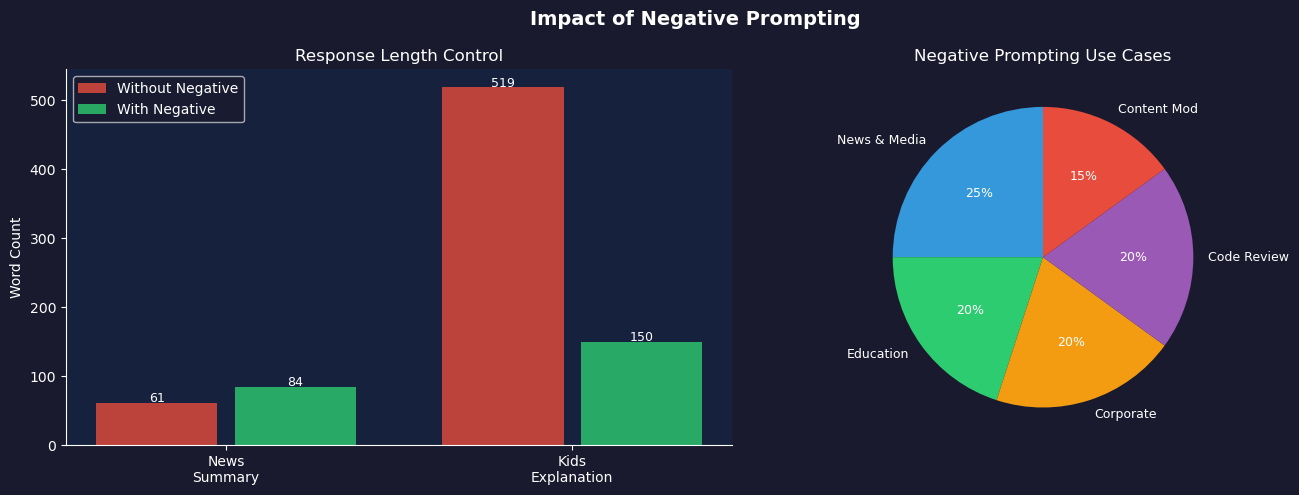

In [12]:
# ── Visualization: Impact of Negative Prompting ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

# Word count comparison
ax1 = axes[0]
ax1.set_facecolor('#16213e')
categories = ['News\nSummary', 'Kids\nExplanation']
without_counts = [len(without_neg.split()), len(without_edu.split())]
with_counts    = [len(with_neg.split()),    len(with_edu_neg.split())]

x = range(len(categories))
bars1 = ax1.bar([i-0.2 for i in x], without_counts, 0.35,
                label='Without Negative', color='#e74c3c', alpha=0.8)
bars2 = ax1.bar([i+0.2 for i in x], with_counts, 0.35,
                label='With Negative', color='#2ecc71', alpha=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(categories, color='white')
ax1.set_ylabel('Word Count', color='white')
ax1.set_title('Response Length Control', color='white', fontsize=12)
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1a1a2e', labelcolor='white')
[ax1.spines[s].set_color('white') for s in ['bottom', 'left']]
[ax1.spines[s].set_visible(False) for s in ['top', 'right']]
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(int(bar.get_height())), ha='center', color='white', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(int(bar.get_height())), ha='center', color='white', fontsize=9)

# Use cases pie chart
ax2 = axes[1]
ax2.set_facecolor('#16213e')
use_cases = ['News & Media', 'Education', 'Corporate', 'Code Review', 'Content Mod']
sizes     = [25, 20, 20, 20, 15]
colors_pie = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']
wedges, texts, autotexts = ax2.pie(
    sizes, labels=use_cases, colors=colors_pie,
    autopct='%1.0f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 9}
)
for at in autotexts:
    at.set_color('white')
ax2.set_title('Negative Prompting Use Cases', color='white', fontsize=12)

plt.suptitle('Impact of Negative Prompting', color='white',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('negative_prompting_analysis.png', dpi=120,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 4. Interactive Playground — All Techniques <a id='4'></a>

**Try all 7 prompt engineering techniques live!**

Select a technique, type your prompt, and see the result instantly.
The playground automatically applies the right prompt structure for each technique!

In [30]:
# ============================================================
#  INTERACTIVE PROMPT ENGINEERING PLAYGROUND
# Supports all 7 techniques with real-time API calls
# ============================================================

# ── Style ─────────────────────────────────────────────────────
STYLE = """
<style>
.playground-header {
    background: linear-gradient(135deg, #1a1a2e, #16213e);
    color: white;
    padding: 15px;
    border-radius: 10px;
    margin-bottom: 10px;
    font-family: monospace;
}
</style>
"""
from IPython.display import HTML
display(HTML(STYLE))

# ── Technique descriptions ─────────────────────────────────────
TECHNIQUE_INFO = {
    'Zero-Shot'         : 'Ask directly without examples. Best for: simple Q&A, translation, classification.',
    'Few-Shot'          : 'Give 2-3 examples first. Best for: custom formats, domain-specific tasks.',
    'Chain-of-Thought'  : 'Add step-by-step reasoning. Best for: math, logic, complex decisions.',
    'Role-Based'        : 'Assign expert persona. Best for: specialized knowledge, consistent style.',
    'Structured Output' : 'Get JSON/table output. Best for: data extraction, API integration.',
    'ReAct'             : 'Thought→Action→Observation loop. Best for: agents, multi-step planning.',
    'Negative'          : 'Tell model what to avoid. Best for: content control, style constraints.'
}

EXAMPLE_PROMPTS = {
    'Zero-Shot'         : 'Classify this review as POSITIVE, NEGATIVE, or NEUTRAL:\n"The product works great but delivery was slow."',
    'Few-Shot'          : 'Classify these emails as SPAM or NOT SPAM.\n\nExamples:\n"Meeting at 3pm" → NOT SPAM\n"Win $1000 now!" → SPAM\n\nNow classify:\n"Your account needs verification"',
    'Chain-of-Thought'  : 'A store has 50 apples. They sell 30% in the morning and 40% of remaining in afternoon. How many are left?',
    'Role-Based'        : 'What is machine learning?',
    'Structured Output' : 'List 3 Python libraries for data science with their use cases.',
    'ReAct'             : 'A website is loading slowly. Users are complaining. The server CPU is at 90%. A new update was deployed 1 hour ago.',
    'Negative'          : 'Explain artificial intelligence to a general audience.'
}

EXAMPLE_ROLES = {
    'Zero-Shot'         : '',
    'Few-Shot'          : '',
    'Chain-of-Thought'  : '',
    'Role-Based'        : 'You are a senior data scientist with 10 years of experience. Explain concepts clearly with practical examples.',
    'Structured Output' : '',
    'ReAct'             : 'You are a senior DevOps engineer. Investigate systematically.',
    'Negative'          : ''
}

# ── Apply technique logic ──────────────────────────────────────
def apply_technique(technique, prompt, role, negative_rules):
    system = role.strip() if role.strip() else None

    if technique == 'Zero-Shot':
        final = prompt

    elif technique == 'Few-Shot':
        # Check if user already added examples
        if '→' in prompt or 'Example' in prompt:
            final = prompt
        else:
            final = f"""Here are some examples to guide your response:
Example 1: [Input 1] → [Output 1]
Example 2: [Input 2] → [Output 2]

Now answer:
{prompt}"""

    elif technique == 'Chain-of-Thought':
        final = f"""{prompt}

Think step by step. Show your reasoning clearly at each step before giving the final answer.
Format:
Step 1: [reasoning]
Step 2: [reasoning]
...
Final Answer: [answer]"""

    elif technique == 'Role-Based':
        final = prompt

    elif technique == 'Structured Output':
        final = f"""{prompt}

Respond ONLY in this JSON format — no extra text:
{{
  "answer": "main answer here",
  "key_points": ["point 1", "point 2", "point 3"],
  "example": "a practical example",
  "difficulty": "beginner/intermediate/advanced"
}}"""

    elif technique == 'ReAct':
        final = f"""{prompt}

Use the ReAct format to solve this:

Thought 1: [analyze what you know]
Action 1: [what to investigate first]
Observation 1: [what this reveals]

Thought 2: [next analysis]
Action 2: [next step]
Observation 2: [finding]

Thought 3: [conclusion reasoning]
Action 3: [final check]
Observation 3: [conclusion]

Final Answer: [clear, actionable solution]"""

    elif technique == 'Negative':
        rules = negative_rules.strip()
        if not rules:
            rules = "Do NOT use technical jargon\nDo NOT exceed 3 sentences\nDo NOT be vague"
        rule_lines = '\n'.join([f'- {r.strip()}' for r in rules.split('\n') if r.strip()])
        final = f"""{prompt}

Rules (strictly follow these):
{rule_lines}"""

    else:
        final = prompt

    return final, system


# ── UI Components ──────────────────────────────────────────────
technique_dd = widgets.Dropdown(
    options=list(TECHNIQUE_INFO.keys()),
    value='Zero-Shot',
    description='Technique:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)

info_label = widgets.HTML(
    value=f'<span style="color:#2ecc71;font-size:12px"> {TECHNIQUE_INFO["Zero-Shot"]}</span>',
    layout=widgets.Layout(width='600px')
)

prompt_box = widgets.Textarea(
    value=EXAMPLE_PROMPTS['Zero-Shot'],
    description='Your Prompt:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='620px', height='120px')
)

role_box = widgets.Text(
    value='',
    description='Role/System:',
    placeholder='Optional: e.g. You are an expert Python developer...',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='620px')
)

negative_box = widgets.Textarea(
    value='',
    description='Negative Rules:',
    placeholder='For Negative technique: one rule per line\ne.g. Do NOT use jargon\nDo NOT exceed 3 sentences',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='620px', height='80px')
)

temp_slider = widgets.FloatSlider(
    value=0.7, min=0.0, max=1.0, step=0.1,
    description='Temperature:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

load_example_btn = widgets.Button(
    description='Load Example',
    button_style='info',
    layout=widgets.Layout(width='140px', height='35px')
)

run_btn = widgets.Button(
    description='Run Prompt',
    button_style='success',
    layout=widgets.Layout(width='130px', height='35px')
)

clear_btn = widgets.Button(
    description='Clear',
    button_style='warning',
    layout=widgets.Layout(width='90px', height='35px')
)

output_area = widgets.Output(
    layout=widgets.Layout(
        border='1px solid #2ecc71',
        padding='10px',
        border_radius='8px',
        min_height='100px'
    )
)

# ── Event Handlers ────────────────────────────────────────────
def on_technique_change(change):
    tech = change['new']
    info_label.value = f'<span style="color:#2ecc71;font-size:12px">{TECHNIQUE_INFO[tech]}</span>'
    # Auto-fill role for relevant techniques
    role_box.value = EXAMPLE_ROLES.get(tech, '')
    # Show/hide negative rules box
    negative_box.layout.display = 'flex' if tech == 'Negative' else 'none'

technique_dd.observe(on_technique_change, names='value')

def on_load_example(b):
    tech = technique_dd.value
    prompt_box.value = EXAMPLE_PROMPTS.get(tech, '')
    role_box.value   = EXAMPLE_ROLES.get(tech, '')

load_example_btn.on_click(on_load_example)

def on_clear(b):
    with output_area:
        clear_output()

clear_btn.on_click(on_clear)

def on_run(b):
    with output_area:
        clear_output()
        tech     = technique_dd.value
        prompt   = prompt_box.value.strip()
        role     = role_box.value.strip()
        neg_rules = negative_box.value.strip()
        temp     = temp_slider.value

        if not prompt:
            print(' Please enter a prompt first!')
            return

        print(f'Running [{tech}] prompt...\n')

        try:
            final_prompt, system = apply_technique(tech, prompt, role, neg_rules)

            response = ask(final_prompt, system=system, temperature=temp)

            print('═' * 60)
            print(f' Technique  : {tech}')
            print(f'  Temperature: {temp}')
            if system:
                print(f' Role       : {system[:80]}...' if len(system) > 80 else f' Role: {system}')
            print('─' * 60)
            print(f' Final Prompt Sent:\n{final_prompt}')
            print('─' * 60)
            print(f' Model Response:\n{response}')
            print('═' * 60)
            print(f'\n Stats: {len(response.split())} words | {len(response)} chars')

        except Exception as e:
            print(f'Error: {e}')

run_btn.on_click(on_run)

# Hide negative box initially
negative_box.layout.display = 'none'

# ── Layout ────────────────────────────────────────────────────
header = widgets.HTML("""
<div style='background:linear-gradient(135deg,#1a1a2e,#16213e);
            padding:15px; border-radius:10px; margin-bottom:10px;'>
    <h3 style='color:#2ecc71; margin:0;'> Prompt Engineering Interactive Playground</h3>
    <p style='color:#bbb; margin:5px 0 0 0; font-size:13px;'>
        Select a technique → Load or type your prompt → Click Run!
    </p>
</div>
""")

buttons_row = widgets.HBox([load_example_btn, run_btn, clear_btn],
                           layout=widgets.Layout(gap='10px'))

ui = widgets.VBox([
    header,
    technique_dd,
    info_label,
    prompt_box,
    role_box,
    negative_box,
    temp_slider,
    buttons_row,
    widgets.HTML('<b style="color:#aaa"> Output:</b>'),
    output_area
], layout=widgets.Layout(gap='8px', padding='10px'))

display(ui)
print('Playground ready! Select a technique and click Run Prompt')

Playground ready! Select a technique and click Run Prompt


---
## 5. Visualization — Technique Comparison <a id='5'></a>

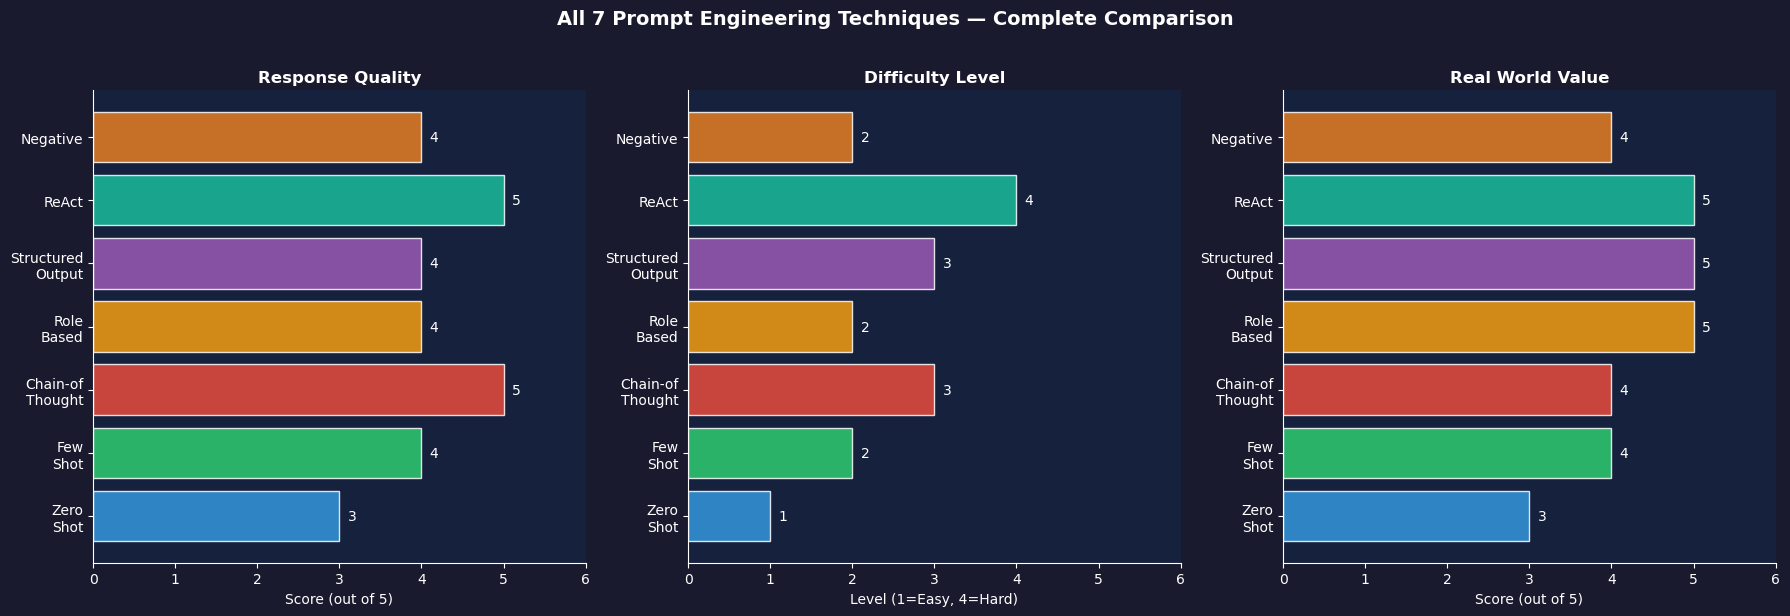

In [31]:
# ── Complete Technique Comparison Chart ───────────────────────
techniques  = ['Zero\nShot', 'Few\nShot', 'Chain-of\nThought',
               'Role\nBased', 'Structured\nOutput', 'ReAct', 'Negative']
quality     = [3, 4, 5, 4, 4, 5, 4]
difficulty  = [1, 2, 3, 2, 3, 4, 2]
real_world  = [3, 4, 4, 5, 5, 5, 4]
colors      = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')

for ax, data, title, xlabel in [
    (axes[0], quality,    'Response Quality', 'Score (out of 5)'),
    (axes[1], difficulty, 'Difficulty Level', 'Level (1=Easy, 4=Hard)'),
    (axes[2], real_world, 'Real World Value', 'Score (out of 5)')
]:
    ax.set_facecolor('#16213e')
    bars = ax.barh(techniques, data, color=colors, edgecolor='white', alpha=0.85)
    ax.set_xlabel(xlabel, color='white', fontsize=10)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax.tick_params(colors='white')
    [ax.spines[s].set_color('white') for s in ['bottom', 'left']]
    [ax.spines[s].set_visible(False) for s in ['top', 'right']]
    ax.set_xlim(0, 6)
    for bar, val in zip(bars, data):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                str(val), va='center', color='white', fontsize=10)

plt.suptitle('All 7 Prompt Engineering Techniques — Complete Comparison',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('complete_comparison.png', dpi=120,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

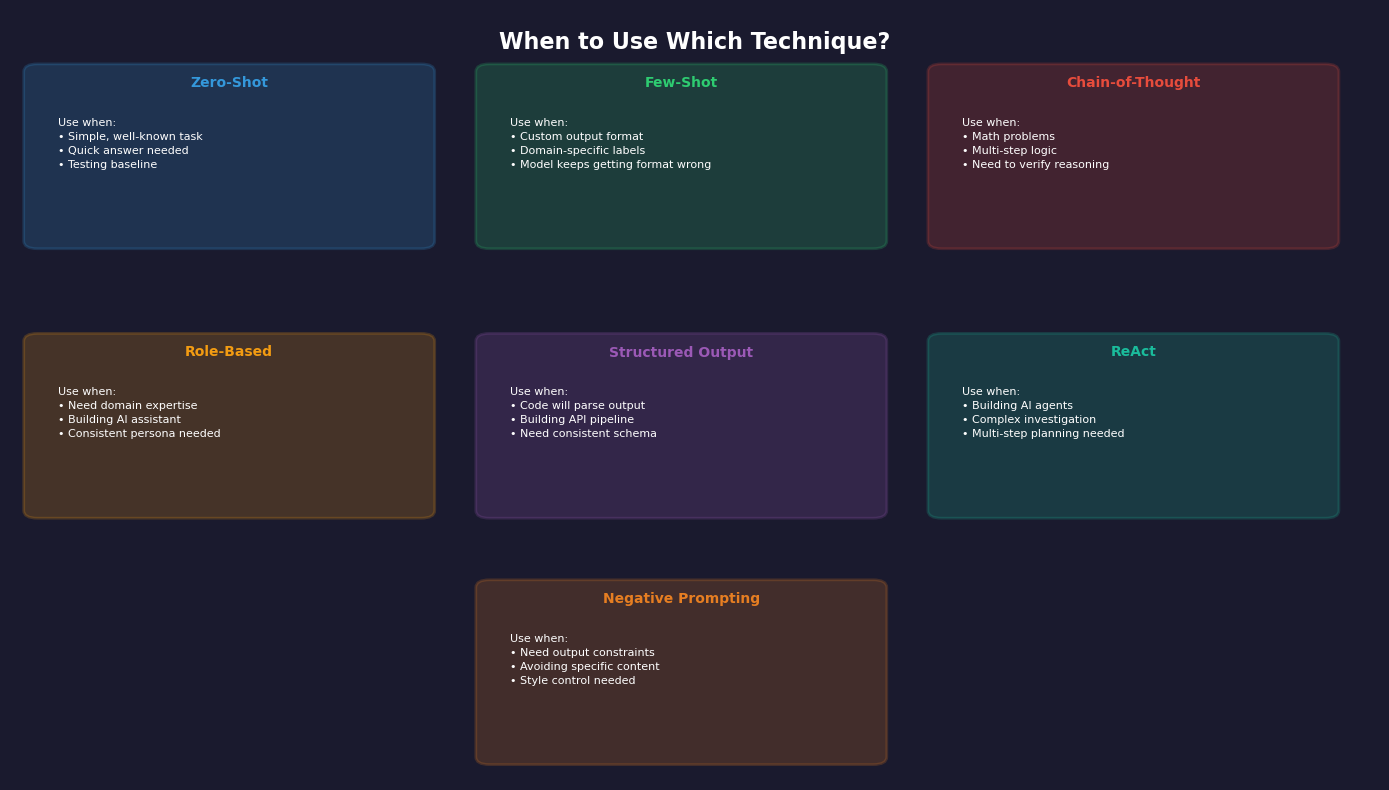

In [32]:
# ── When to Use Which Technique ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'When to Use Which Technique?',
        ha='center', fontsize=16, color='white', fontweight='bold')

# Cards
cards = [
    (0.2, 7.0, 'Zero-Shot',
     'Use when:\n• Simple, well-known task\n• Quick answer needed\n• Testing baseline',
     '#3498db'),
    (3.5, 7.0, 'Few-Shot',
     'Use when:\n• Custom output format\n• Domain-specific labels\n• Model keeps getting format wrong',
     '#2ecc71'),
    (6.8, 7.0, 'Chain-of-Thought',
     'Use when:\n• Math problems\n• Multi-step logic\n• Need to verify reasoning',
     '#e74c3c'),
    (0.2, 3.5, 'Role-Based',
     'Use when:\n• Need domain expertise\n• Building AI assistant\n• Consistent persona needed',
     '#f39c12'),
    (3.5, 3.5, 'Structured Output',
     'Use when:\n• Code will parse output\n• Building API pipeline\n• Need consistent schema',
     '#9b59b6'),
    (6.8, 3.5, 'ReAct',
     'Use when:\n• Building AI agents\n• Complex investigation\n• Multi-step planning needed',
     '#1abc9c'),
    (3.5, 0.3, 'Negative Prompting',
     'Use when:\n• Need output constraints\n• Avoiding specific content\n• Style control needed',
     '#e67e22'),
]

for x, y, title, content, color in cards:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), 2.8, 2.2,
        boxstyle='round,pad=0.1',
        facecolor=color, alpha=0.2,
        edgecolor=color, linewidth=2
    ))
    ax.text(x+1.4, y+2.0, title,
            ha='center', fontsize=10, color=color, fontweight='bold')
    ax.text(x+0.15, y+1.6, content,
            ha='left', va='top', fontsize=8, color='white',
            linespacing=1.5)

plt.tight_layout()
plt.savefig('when_to_use.png', dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 6. Summary & Cheat Sheet <a id='6'></a>

In [33]:
print('''
====================================================================
||            PROMPT ENGINEERING — COMPLETE CHEAT SHEET           ||
||================================================================||
||                                                                ||
||      Zero-Shot    → Ask directly. No examples.                 ||
||                   "Classify this as SPAM or NOT SPAM: ..."     ||
||                                                                ||
||     Few-Shot     → Give 2-3 examples first, then ask.          ||
||                   "Email A → SPAM\nEmail B → NOT SPAM\nNow: ..."|
||                                                                ||
||     Chain-of-    → Add step-by-step reasoning.                 ||
||    Thought        "Think step by step..."                      ||
||                                                                ||
||     Role-Based   → "You are a [expert]..." in system message.  ||
||                   Shifts vocabulary, depth, and style.         ||
||                                                                ||
||     Structured   → "Respond ONLY in JSON format: {...}"        ||
||    Output         Makes output machine-readable.               ||
||                                                                ||
||     ReAct        → Thought→Action→Observation loop.            ||
||                   Foundation of AI Agents.                     ||
||                                                                ||
||      Negative     → "Do NOT use jargon. Do NOT exceed 3 lines."||
||                   Controls what model avoids.                  ||
||                                                                ||
||================================================================||
||    Pro Tips:                                                   ||
|| • Combine techniques for best results                          ||
|| • Use temp=0.0 for facts, temp=0.7+ for creativity             ||
|| • Always validate JSON/structured output with try/except       ||
|| • Test prompts iteratively — small changes make big difference ||
||================================================================||
||     Temperature Guide:                                         ||
|| 0.0 → Classification, extraction, JSON                         ||
|| 0.3 → Technical writing, summaries                             ||
|| 0.7 → Conversations, explanations                              ||
|| 1.0 → Creative writing, brainstorming                          ||
||================================================================||

 Next Steps:
   → Self-Consistency: Generate multiple responses, pick majority
   → Tree of Thoughts: Explore multiple reasoning paths
   → RAG: Give model access to your documents
   → Function Calling: Let LLMs call real APIs

 Built for GSSoC 2026 — ML-CaPsule
''')


||            PROMPT ENGINEERING — COMPLETE CHEAT SHEET           ||
||================================================================||
||                                                                ||
||      Zero-Shot    → Ask directly. No examples.                 ||
||                   "Classify this as SPAM or NOT SPAM: ..."     ||
||                                                                ||
||     Few-Shot     → Give 2-3 examples first, then ask.          ||
||                   "Email A → SPAM
Email B → NOT SPAM
Now: ..."|
||                                                                ||
||     Chain-of-    → Add step-by-step reasoning.                 ||
||    Thought        "Think step by step..."                      ||
||                                                                ||
||     Role-Based   → "You are a [expert]..." in system message.  ||
||                   Shifts vocabulary, depth, and style.         ||
||                                 

---
<div align='center'>

##  Project Summary

| Component | Details |
|-----------|---------|
| **New Techniques** | ReAct + Negative Prompting |
| **Real World Examples** | Medical, DevOps, Business, ML, News, Education, Corporate, Code Review |
| **Interactive Playground** | All 7 techniques with live API calls |
| **Visualizations** | 3 comparison charts + decision guide |
| **LLM** | LLaMA3 via Groq API (Free!) |
| **API Key Security** | getpass (never hardcoded) |

 **Built for GSSoC 2026 — ML-CaPsule**

</div>